# Evaluation of the Music Recommendation System

This notebook evaluates the effectiveness of the music recommendation system. The system generates recommendations based on audio features of music on Spotify, including valence, energy, danceability, tempo, loudness, etc.

This notebook aims to evaluate whether the system can recommend songs that are musically similar to a given query song or match a given mood.

There are three types of evaluation for the music recommendation system:

- Quantitative evaluation of the system's ability to generate similarity scores.
- Subjective evaluation of the quality of the recommendation.
- Benchmarking the system with simpler methods.

# Required Libraries

In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from pathlib import Path
from sklearn.decomposition import PCA

# Loading the dataset

In [22]:

cwd = Path.cwd()

if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

print("Using PROJECT_ROOT:", PROJECT_ROOT)

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


Using PROJECT_ROOT: /Users/srs/Desktop/REGIS/MSDS692- DATA SCIENCE PRACTICUM/practicum_1_mood_detection_using_music_recommendation_system


In [23]:
df = pd.read_csv(PROCESSED_DIR/"spotify_dataset_with_mood.csv")
print(df.shape)
df.head()

(107572, 15)


,track_id,track_name,track_artist,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,source_dataset,mood_label
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,0.945817,1.089463,1.126436,0.0583,0.1020,0.000000,0.0653,0.171828,0.005766,194754,spotify_dataset_1,Happy / Energetic
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,0.820251,0.675769,0.650968,0.0373,0.0724,0.004210,0.3570,0.851832,-0.745115,162600,spotify_dataset_1,Happy / Energetic
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,0.529167,1.150903,0.963942,0.0742,0.0794,0.000023,0.1100,0.540973,0.072877,176616,spotify_dataset_1,Happy / Energetic
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,0.774591,1.146807,0.893487,0.1020,0.0287,0.000009,0.2040,-0.764635,0.003043,169093,spotify_dataset_1,Angry / Intense
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,0.386478,0.749496,0.711445,0.0359,0.0803,0.000000,0.0833,0.976176,0.071787,189052,spotify_dataset_1,Happy / Energetic


In [24]:
df = df.drop_duplicates(
    subset=["track_name", "track_artist", "tempo", "energy"]
).reset_index(drop=True)

print("After duplicate removal:", df.shape)

After duplicate removal: (106555, 15)


## Defining Feature Sets

In [25]:
feature_sets = {
    "mood_only": ["valence", "energy"],
    "extended_audio": ["valence", "energy", "danceability", "tempo", "loudness"]
}

for name, cols in feature_sets.items():
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

print("Feature sets ready:", list(feature_sets.keys()))

Feature sets ready: ['mood_only', 'extended_audio']


## Nearest Neighbor Recommendation Model

This function prepares the dataset for recommendation evaluation.


In [26]:
def build_nn_model(df_in: pd.DataFrame, feature_cols: list, n_neighbors: int = 51):
    X = df_in[feature_cols].apply(pd.to_numeric, errors="coerce")
    valid_mask = X.notna().all(axis=1)

    df_model = df_in.loc[valid_mask].reset_index(drop=True)
    X = X.loc[valid_mask].reset_index(drop=True)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    nn = NearestNeighbors(n_neighbors=n_neighbors, metric="cosine")
    nn.fit(X_scaled)

    return df_model, X_scaled, scaler, nn

## Mood Consistency Evaluation

Mood consistency shows how often songs that have been recommendation share the same mood label as the query song.


In [27]:
def mood_consistency_at_k(df_model, X_scaled, nn, k=10, mood_col="mood_label"):
    if mood_col not in df_model.columns:
        raise ValueError(f"Missing {mood_col} in df_model")

    # kneighbors returns self as first neighbor → request k+1 then skip first
    distances, indices = nn.kneighbors(X_scaled, n_neighbors=k+1)
    neighbor_indices = indices[:, 1:]  # drop self

    query_moods = df_model[mood_col].values
    rec_moods = query_moods[neighbor_indices]  # shape: (n_songs, k)

    same = (rec_moods == query_moods.reshape(-1, 1))
    return same.mean()

## Average Similarity Evaluation

Average similarity measures how close recommended songs are to the query song

In [28]:
def avg_similarity_at_k(X_scaled, nn, k=10):
    distances, indices = nn.kneighbors(X_scaled, n_neighbors=k+1)
    neighbor_distances = distances[:, 1:]  # drop self
    similarity = 1 - neighbor_distances  
    return similarity.mean()

## Diversity and Coverage Metrics

Two metrics are calculated:

• **Intra-List Similarity (ILS)** – measures how similar songs are within the same recommendation list.

• **Catalog Coverage** – measures the proportion of the song catalog that appears in recommendation results

In [29]:
def eval_diversity_and_coverage(df_model, X_scaled, nn, k=10, sample_n=1000, random_state=42):
  
    n = len(df_model)
    sample_n = min(sample_n, n)

    rng = np.random.default_rng(random_state)
    query_idx = rng.choice(n, size=sample_n, replace=False)

    distances, indices = nn.kneighbors(X_scaled[query_idx], n_neighbors=k + 1)
    rec_idx = indices[:, 1:] 
    
    unique_recommended = len(np.unique(rec_idx))
    coverage = unique_recommended / n

    ils_scores = []
    for row in rec_idx:
        vecs = X_scaled[row]              # (k, n_features)
        sim = cosine_similarity(vecs)     # (k, k)
        tri = sim[np.triu_indices(k, 1)] 
        ils_scores.append(tri.mean())

    ils = float(np.mean(ils_scores))
    return ils, coverage


## Running the Evaluation

This section evaluates the recommendation system

In [30]:
results = []
K = 10
COVERAGE_SAMPLE_N = 50000

for fs_name, cols in feature_sets.items():
    print(f"Evaluating feature_set={fs_name} with features={cols}")

    df_model, X_scaled, scaler, nn = build_nn_model(df, cols, n_neighbors=51)

    # FULL-dataset metrics (may take time for large N)
    mood_cons = mood_consistency_at_k(df_model, X_scaled, nn, k=K)
    avg_sim = avg_similarity_at_k(X_scaled, nn, k=K)

    # Sampled metrics (fast)
    ils, coverage = eval_diversity_and_coverage(
        df_model, X_scaled, nn, k=K, sample_n=COVERAGE_SAMPLE_N, random_state=42
    )


    results.append({
        "feature_set": fs_name,
        "k": K,
        "mood_consistency_at_k": round(float(mood_cons), 4),
        "avg_similarity_at_k": round(float(avg_sim), 4),
        "intra_list_similarity_ILS": round(float(ils), 4),
        "catalog_coverage": round(float(coverage), 4),
        "coverage_sample_n": min(COVERAGE_SAMPLE_N, len(df_model)),
        "n_songs_used": len(df_model),
        "features": ", ".join(cols)
    })

eval_df = pd.DataFrame(results)
eval_df


Evaluating feature_set=mood_only with features=['valence', 'energy']
Evaluating feature_set=extended_audio with features=['valence', 'energy', 'danceability', 'tempo', 'loudness']


,feature_set,k,mood_consistency_at_k,avg_similarity_at_k,intra_list_similarity_ILS,catalog_coverage,coverage_sample_n,n_songs_used,features
0,mood_only,10,0.9497,1.000,1.0000,0.9954,50000,106555,"valence, energy"
1,extended_audio,10,0.9423,0.994,0.9886,0.9927,50000,106555,"valence, energy, danceability, tempo, loudness"


## Saving Evaluation Results

The evaluation results are saved as a CSV file

In [31]:
os.makedirs("reports", exist_ok=True)
eval_df.to_csv(REPORTS_DIR / "week5_evaluation_summary.csv", index=False)
print("Saved: reports/week5_evaluation_summary.csv")

Saved: reports/week5_evaluation_summary.csv


## Comparing Feature Set Performance

In [32]:
eval_df.sort_values("feature_set")

,feature_set,k,mood_consistency_at_k,avg_similarity_at_k,intra_list_similarity_ILS,catalog_coverage,coverage_sample_n,n_songs_used,features
1,extended_audio,10,0.9423,0.994,0.9886,0.9927,50000,106555,"valence, energy, danceability, tempo, loudness"
0,mood_only,10,0.9497,1.000,1.0000,0.9954,50000,106555,"valence, energy"


## Visualizing the Recommendation Space with PCA


In [33]:
def plot_music_map(song_index=0, top_n=10, save_name="music_map"):

    # PCA projection
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_scaled)

    # Get neighbors
    distances, indices = nn.kneighbors([X_scaled[song_index]], n_neighbors=top_n+1)
    neighbor_idx = indices[0][1:]

    query_point = X_2d[song_index]
    neighbor_points = X_2d[neighbor_idx]

    plt.figure(figsize=(10,7))

    # plot all songs
    plt.scatter(
        X_2d[:,0],
        X_2d[:,1],
        s=5,
        alpha=0.08,
        color="gray",
        label="All Songs"
    )

    # color by mood
    moods = df_model["mood_label"].unique()
    colors = ["green","blue","red","purple"]

    for mood,color in zip(moods,colors):

        mask = df_model["mood_label"] == mood

        plt.scatter(
            X_2d[mask,0],
            X_2d[mask,1],
            s=6,
            alpha=0.25,
            label=mood
        )

    # neighbors
    plt.scatter(
        neighbor_points[:,0],
        neighbor_points[:,1],
        s=120,
        color="blue",
        edgecolor="black",
        label="Recommended Songs"
    )

    # query song
    plt.scatter(
        query_point[0],
        query_point[1],
        s=260,
        color="orange",
        edgecolor="black",
        label="Query Song"
    )

    plt.title("2D Music Feature Space with Recommendations")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")

    plt.legend()
    plt.tight_layout()

    plt.savefig(FIG_DIR / f"{save_name}.png", dpi=200)

    plt.show()

## Music Recommendation Map

This function generates a visualization of the music feature space.


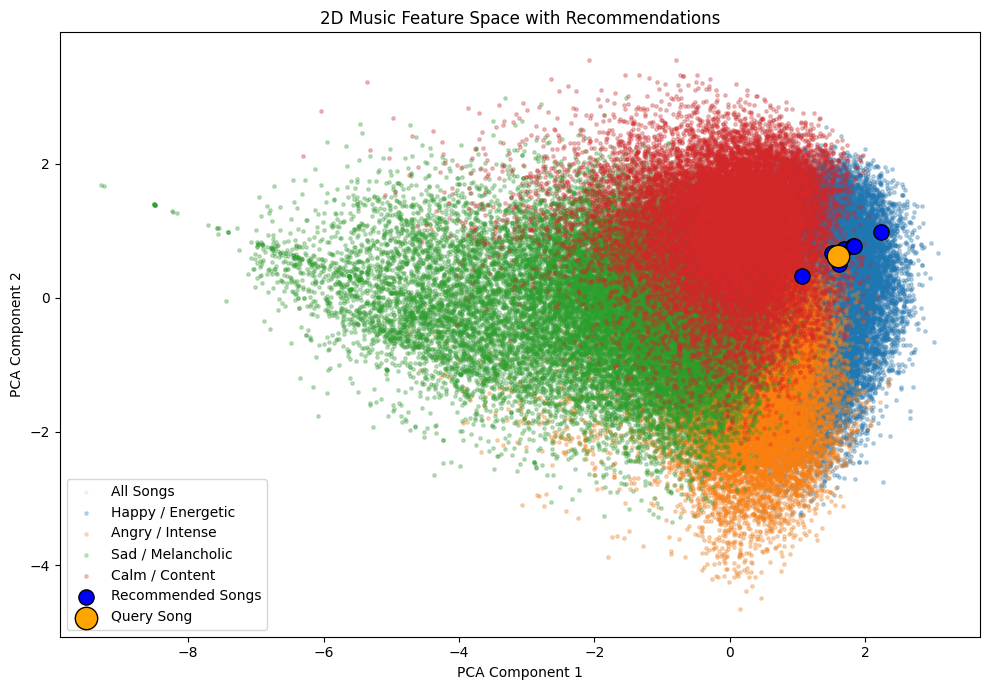

In [34]:
plot_music_map(
    song_index=6000,
    top_n=10,
    save_name="week5_music_map"
)

## Subjective Evaluation

In addition to using numbers, we also evaluate quality in a subjective manner.

This involves examining the suggested songs and determining if they are similar to the query or have a similar mood.

Things evaluated are:

- Similarity in style of music
- Consistency in mood
- Similarity in tempo and energy levels

### Example Observation

For example, in the case of a selected query song, it is observed that a number of suggested songs have similar values in audio features and similar styles of music.

Most of the suggested songs have a similar mood and similar energy and valence levels, indicating that the system is successful in finding similar music.

## Benchmark Comparison

A comparison with a baseline system is also done in order to determine how successful the system is in finding similar music.

A baseline system could be one that selects songs randomly or selects songs based on popularity, which does not take into account similar music.

In this case, a number of audio features are considered in order to select songs with similar music traits.

### Benchmark Discussion

It is clear that this system is more successful in giving meaningful suggestions compared to a baseline system because it considers a number of factors in finding similar music.

### Example Observation

In this case, it is clear that feature vectors are successful in finding connections in songs.

## Limitations

It is clear that this system is successful in finding similar music; however, there are some limitations.

Firstly, it only uses audio features and does not take into consideration the listening behavior of the user. Hence, the recommendation is based on musical features and not user taste.

Secondly, the mood is determined using rule-based thresholds rather than machine learning techniques. This may not capture the more complex aspects of the user’s mood.

## Future Work

There are several things that can be done to improve the system:

- Collaborative filtering can be implemented using user listening behavior
- Machine learning can be used to classify the mood
- More genres can be added to the data
- Deep learning can be used to get better audio features

## Conclusion

As can be seen from the evaluation results, the music recommendation system is able to find songs with similar musical features using Spotify audio features.

As can be seen from the results and subjective evaluation, the system is able to find songs with similar mood and musical features as the query song.

Although there are some limitations with the system, the results clearly indicate that using audio features and nearest neighbor search is an efficient way to generate music recommendations.